Loading weights:   0%|          | 0/534 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: /mnt/volume6/czj/labLGN/LabLZ/esm2_650M
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


device: cuda
Already have 2179 entries, continuing ...
To process: 0 rows


ESM2 local delta: 0it [00:00, ?it/s]

Part A finished: 2179 / 2179
matrix: (2179, 1280)
labeled: (2179, 1280), pos=236, neg=1943


n_comp=  2  CV AUROC=0.568
n_comp=  5  CV AUROC=0.553
n_comp= 10  CV AUROC=0.566
n_comp= 20  CV AUROC=0.571
n_comp= 30  CV AUROC=0.574
n_comp= 50  CV AUROC=0.571
n_comp= 75  CV AUROC=0.592
n_comp=100  CV AUROC=0.594
n_comp=150  CV AUROC=0.578

Best number of components: 100  (AUROC=0.594)


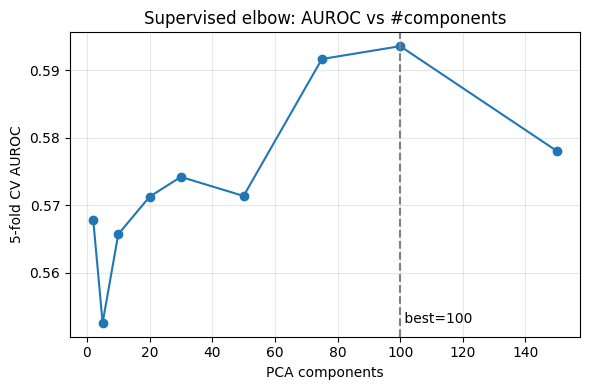

In [ ]:
import os, re, pickle, numpy as np, pandas as pd, torch
from tqdm import tqdm
from transformers import EsmModel, EsmTokenizer

BASE_PATH  = "/mnt/volume6/czj/labLGN/LabLZ/data_preparation/"
INPUT_CSV  = BASE_PATH + "cell2024_model_single_subst.csv"
OUT_PKL    = BASE_PATH + "phase4_esm2_local_delta.pkl" 
MODEL_NAME = "/mnt/volume6/czj/labLGN/LabLZ/models/esm2_650M"
MAX_LEN, WINDOW, SAVE_EVERY = 1022, 7, 100

# Part A: 1280 local delta 
tokenizer = EsmTokenizer.from_pretrained(MODEL_NAME)
model = EsmModel.from_pretrained(MODEL_NAME).eval()
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
if device.type == "cuda": model = model.half()
print(f"device: {device}")

def parse_pos(m):
    if not isinstance(m, str): return None
    mt = re.match(r'^([A-Z])(\d+)([A-Z])$', m.strip())
    return int(mt.group(2)) if mt else None

@torch.no_grad()
def residue_hidden(seq):
    inp = tokenizer(seq, return_tensors="pt", add_special_tokens=True)
    out = model(input_ids=inp["input_ids"].to(device),
                attention_mask=inp["attention_mask"].to(device))
    return out.last_hidden_state[0, 1:-1, :].float().cpu().numpy()   # (L,1280)

# WT cache
_wt_key, _wt_h = None, None
def get_wt_hidden(sub_wt):
    global _wt_key, _wt_h
    if sub_wt != _wt_key:
        _wt_key, _wt_h = sub_wt, residue_hidden(sub_wt)
    return _wt_h

def local_delta(wt_seq, mt_seq, pos):
    # extracts a window of embeddings around the mutation site and calculates the mean difference between the mt and wt embeddings
    L = len(wt_seq)
    if L <= MAX_LEN:
        start, sub_wt, sub_mt = 0, wt_seq, mt_seq
    else:
        start = min(max(pos - 1 - MAX_LEN // 2, 0), L - MAX_LEN)
        sub_wt, sub_mt = wt_seq[start:start+MAX_LEN], mt_seq[start:start+MAX_LEN]
    idx = (pos - 1) - start
    if idx < 0 or idx >= len(sub_wt): return None
    h_wt, h_mt = get_wt_hidden(sub_wt), residue_hidden(sub_mt)
    n = min(len(h_wt), len(h_mt))
    if idx >= n: return None
    lo, hi = max(idx - WINDOW, 0), min(idx + WINDOW + 1, n)
    return (h_mt[lo:hi] - h_wt[lo:hi]).mean(axis=0).astype(np.float32)   # (1280,)

df = pd.read_csv(INPUT_CSV).sort_values(["Uniprot", "Variant"]).reset_index(drop=True)
df["KEY"] = df["Gene"].astype(str) + "||" + df["Variant"].astype(str)

store = pickle.load(open(OUT_PKL, "rb")) if os.path.exists(OUT_PKL) else {}
if store: print(f"Already have {len(store)} entries, continuing ...")
todo = df[~df["KEY"].isin(store.keys())]
print(f"To process: {len(todo)} rows")

for count, (_, row) in enumerate(tqdm(todo.iterrows(), total=len(todo), desc="ESM2 local delta")):
    pos, wt, mt = parse_pos(row.get("Mutation_used")), row.get("sequence"), row.get("mutant_sequence")
    vec = None
    if pos and isinstance(wt, str) and isinstance(mt, str):
        try: vec = local_delta(wt, mt, pos)
        except Exception as e: tqdm.write(f"  ✗ {row['KEY']}: {str(e)[:50]}")
    store[row["KEY"]] = vec
    if (count + 1) % SAVE_EVERY == 0 or (count + 1) == len(todo):
        tmp = OUT_PKL + ".tmp"; pickle.dump(store, open(tmp, "wb")); os.replace(tmp, OUT_PKL)
        tqdm.write(f"{count + 1}/{len(todo)}")

ok = sum(v is not None for v in store.values())
print(f"Part A finished: {ok} / {len(store)}")

# Part B: supervised AUROC vs PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

keys = [k for k, v in store.items() if v is not None]
X = np.vstack([store[k] for k in keys])
print("matrix:", X.shape)

lab = (df.set_index("KEY")["Mislocalized"])
y = lab.reindex(keys).values
mask = ~pd.isna(y)
Xm, ym = X[mask], y[mask].astype(int)
print(f"labeled: {Xm.shape}, pos={ym.sum()}, neg={(ym==0).sum()}")

gene     = df.set_index("KEY")["Gene"].reindex(keys).values
groups_m = gene[mask]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)   # ← 不要放 groups
ns = [nc for nc in [2, 5, 10, 20, 30, 50, 75, 100, 150] if nc < min(Xm.shape)]
aucs = []
for nc in ns:
    pipe = make_pipeline(StandardScaler(),
                         PCA(n_components=nc, random_state=0),
                         LogisticRegression(max_iter=2000, class_weight="balanced"))
    auc = cross_val_score(pipe, Xm, ym,
                          groups=groups_m,      # ← groups 放这里
                          cv=cv, scoring="roc_auc").mean()
    aucs.append(auc); print(f"n_comp={nc:3d}  CV AUROC={auc:.3f}")

best = ns[int(np.argmax(aucs))]
print(f"\nBest number of components: {best}  (AUROC={max(aucs):.3f})")

plt.figure(figsize=(6, 4))
plt.plot(ns, aucs, marker="o")
plt.axvline(best, ls="--", c="grey"); plt.text(best, min(aucs), f" best={best}")
plt.xlabel("PCA components"); plt.ylabel("5-fold CV AUROC")
plt.title("Supervised elbow: AUROC vs #components")
plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(BASE_PATH + "pca_auroc_curve.png", dpi=150); plt.show()